# Optimization for Machine Learning

## Why Optimization?

Training a neural network IS an optimization problem:
$$\hat{\theta} = \arg\min_\theta \mathcal{L}(\theta; X, y)$$

Every advance in deep learning (better models, faster training, more stable convergence) is partly an optimization advance. Understanding optimizers deeply is essential for ML practitioners.

---

## Table of Contents
1. Convex vs Non-Convex Optimization
2. Gradient Descent
3. Stochastic Gradient Descent (SGD) & Mini-batch GD
4. Momentum
5. RMSprop
6. Adam Optimizer
7. AdaGrad, AdaDelta, Nadam, AdamW
8. Learning Rate Schedules
9. Second-Order Methods
10. Constrained Optimization
11. Practical Tips

## 1. Convex vs Non-Convex Optimization

### Convex Function
A function $f$ is **convex** if for all $x, y$ and $\lambda \in [0,1]$:
$$f(\lambda x + (1-\lambda)y) \leq \lambda f(x) + (1-\lambda) f(y)$$

Equivalently (for differentiable $f$): $f''(x) \geq 0$ (positive curvature)

**Properties of convex optimization:**
- Any local minimum is a global minimum
- Gradient descent converges to the global minimum
- Examples: MSE loss for linear regression, logistic loss

### Non-Convex Functions
Neural network loss landscapes are **highly non-convex**:
- Many local minima
- Saddle points (gradient=0 but not a min)
- Flat regions (vanishing gradients)
- Sharp cliffs (exploding gradients)

**Key insight for deep learning:** In high dimensions, saddle points are exponentially more common than local minima. Most local minima have similar loss values. SGD with noise helps escape saddle points.

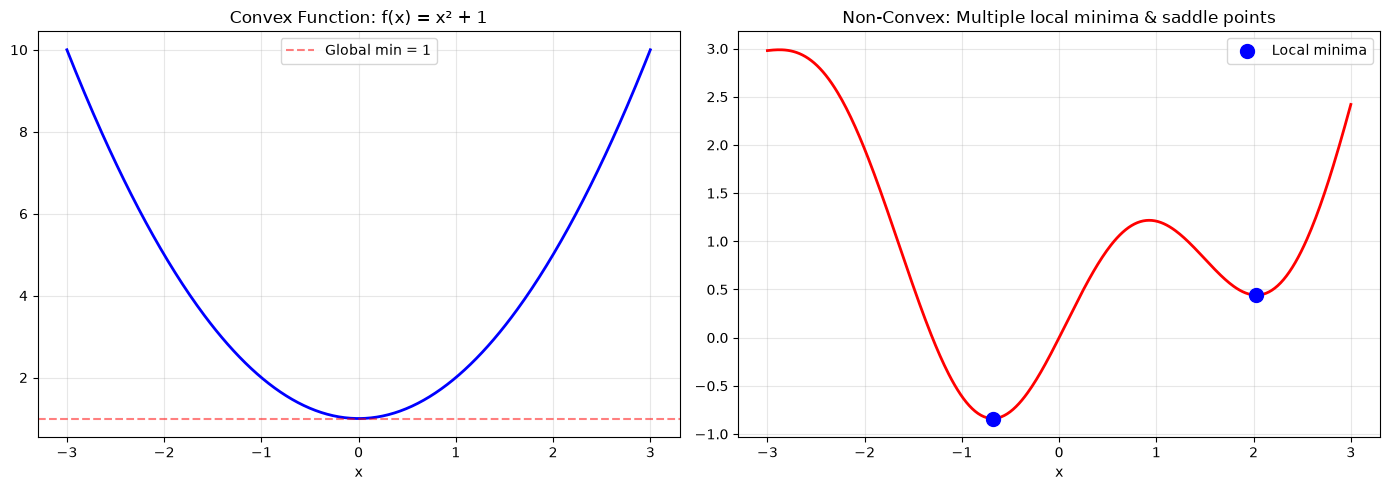

Convexity check via 2nd derivative:
  x= 0.0: f''_convex=2.00 (>0 ✓), f''_nonconvex=0.600
  x= 1.0: f''_convex=2.00 (>0 ✓), f''_nonconvex=-3.037
  x=-1.0: f''_convex=2.00 (>0 ✓), f''_nonconvex=4.237


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize convex vs non-convex
x = np.linspace(-3, 3, 400)

convex = x**2 + 1
non_convex = np.sin(2*x) + 0.3*x**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, convex, 'b-', linewidth=2)
axes[0].axhline(1, color='red', linestyle='--', alpha=0.5, label='Global min = 1')
axes[0].set_title('Convex Function: f(x) = x² + 1', fontsize=12)
axes[0].set_xlabel('x')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, non_convex, 'r-', linewidth=2)
local_mins = x[np.where((non_convex[1:-1] < non_convex[:-2]) & (non_convex[1:-1] < non_convex[2:]))[0] + 1]
local_vals = non_convex[np.where((non_convex[1:-1] < non_convex[:-2]) & (non_convex[1:-1] < non_convex[2:]))[0] + 1]
axes[1].scatter(local_mins, local_vals, c='blue', s=100, zorder=5, label='Local minima')
axes[1].set_title('Non-Convex: Multiple local minima & saddle points', fontsize=12)
axes[1].set_xlabel('x')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Convexity test: second derivative
print("Convexity check via 2nd derivative:")
x_test = np.array([0.0, 1.0, -1.0])
d2_convex = 2 * np.ones_like(x_test)  # f''(x) = 2 > 0 always
d2_non_convex = -4*np.sin(2*x_test) + 0.6  # can be negative
for xi, d2c, d2nc in zip(x_test, d2_convex, d2_non_convex):
    print(f"  x={xi:4.1f}: f''_convex={d2c:.2f} (>0 ✓), f''_nonconvex={d2nc:.3f}")

## 2. Gradient Descent

### Batch Gradient Descent
$$\theta_{t+1} = \theta_t - \alpha \nabla_\theta \mathcal{L}(\theta_t)$$

where $\mathcal{L}(\theta) = \frac{1}{n}\sum_{i=1}^n \ell(\theta; x_i, y_i)$

**Pros:** Stable convergence, exact gradient
**Cons:** Very slow on large datasets (needs full pass per step)

### Convergence Rate
For $L$-smooth convex functions with learning rate $\alpha \leq 1/L$:
$$\mathcal{L}(\theta_T) - \mathcal{L}(\theta^*) \leq \frac{\|\theta_0 - \theta^*\|^2}{2\alpha T}$$

**O(1/T) convergence** for convex, **linear convergence** for strongly convex.

### Choosing Learning Rate
- Too large: diverge (oscillate or explode)
- Too small: very slow convergence
- **Goldilocks range:** $\alpha < 2/L$ where $L$ is the Lipschitz constant of $\nabla\mathcal{L}$

## 3. Stochastic & Mini-batch Gradient Descent

### Stochastic GD (SGD)
Use a **single sample** per step:
$$\theta_{t+1} = \theta_t - \alpha \nabla_\theta \ell(\theta_t; x_i, y_i)$$

**Pros:** Each step is cheap, noise helps escape local minima
**Cons:** Very noisy gradient estimates, oscillations

### Mini-batch GD
Use a **batch** of $B$ samples ($B$ typically 32-512):
$$\nabla_\theta \hat{\mathcal{L}} = \frac{1}{B}\sum_{i \in \mathcal{B}} \nabla_\theta \ell(\theta; x_i, y_i)$$

**Variance of gradient estimate:** $\text{Var}[\hat{g}] = \frac{1}{B}\text{Var}[g_i]$

Larger batch → lower variance → less noise but less regularization effect.

## 4. Momentum

Momentum accumulates a velocity vector to dampen oscillations and accelerate along consistent gradients.

### Classical Momentum
$$v_t = \beta v_{t-1} + (1-\beta) \nabla_\theta \mathcal{L}(\theta_t)$$
$$\theta_{t+1} = \theta_t - \alpha v_t$$

Or equivalently (common PyTorch formulation):
$$v_t = \beta v_{t-1} + \nabla_\theta \mathcal{L}(\theta_t), \quad \theta_{t+1} = \theta_t - \alpha v_t$$

Typical $\beta = 0.9$.

**Intuition:** Like a ball rolling downhill it accumulates speed in consistent directions and dampens oscillations in inconsistent directions.

### Nesterov Accelerated Gradient (NAG)
"Look ahead" compute gradient at the anticipated future position:
$$v_t = \beta v_{t-1} + \alpha \nabla_\theta \mathcal{L}(\theta_t - \beta v_{t-1})$$
$$\theta_{t+1} = \theta_t - v_t$$

Faster convergence: $O(1/T^2)$ vs $O(1/T)$ for convex problems.

## 5. RMSprop

**Adaptive learning rates** divide by running average of squared gradients:

$$v_t = \beta v_{t-1} + (1-\beta) g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{v_t + \epsilon}} g_t$$

where $g_t = \nabla_\theta \mathcal{L}(\theta_t)$, $\beta = 0.9$, $\epsilon = 10^{-8}$.

**Intuition:** Parameters with large recent gradients get smaller effective learning rates (prevents overshooting). Parameters with small gradients get larger effective learning rates (prevents stalling).

**Good for:** RNNs, non-stationary objectives.

## 6. Adam Optimizer

**Adam = Momentum + RMSprop** the most widely used optimizer in deep learning.

### Full Algorithm
Initialize: $m_0 = 0$, $v_0 = 0$, $t = 0$

**Step 1:** Compute gradient: $g_t = \nabla_\theta \mathcal{L}(\theta_t)$

**Step 2:** First moment (biased): $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$

**Step 3:** Second moment (biased): $v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$

**Step 4:** Bias correction:
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Step 5:** Update:
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

**Default hyperparameters:** $\alpha = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$

**Why bias correction?** At the start ($t$ small), $m_t$ and $v_t$ are biased toward zero since they're initialized at 0. The correction $\frac{1}{1-\beta^t}$ inflates them back to proper scale.

### AdamW (Weight Decay)
Standard Adam applies L2 regularization inside the adaptive step, which interacts with the adaptivity. **AdamW** decouples weight decay:
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t - \alpha \lambda \theta_t$$

**AdamW is the default optimizer for transformer training** (BERT, GPT, etc.).

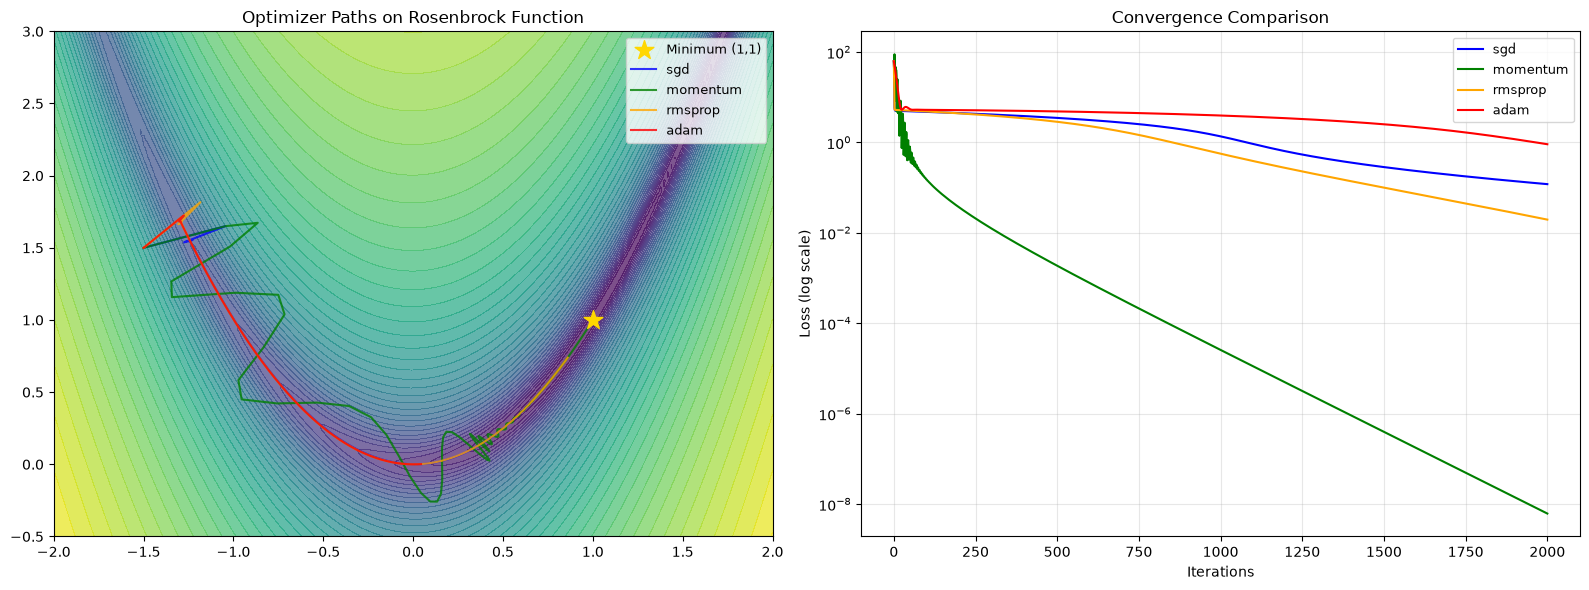

Final losses:
  sgd       : 0.1197
  momentum  : 0.0000
  rmsprop   : 0.0197
  adam      : 0.9141


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Implement all optimizers from scratch and compare
def rosenbrock(x, y):
    return (1 - x)**2 + 100*(y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2*(1-x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

def optimize(optimizer_name, n_steps=2000, lr=0.001):
    theta = np.array([-1.5, 1.5])
    m = np.zeros(2)  # first moment
    v = np.zeros(2)  # second moment
    path = [theta.copy()]
    
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    
    for t in range(1, n_steps+1):
        g = rosenbrock_grad(*theta)
        
        if optimizer_name == 'sgd':
            theta = theta - lr * g
            
        elif optimizer_name == 'momentum':
            m = beta1 * m + g
            theta = theta - lr * m
            
        elif optimizer_name == 'rmsprop':
            v = beta2 * v + (1-beta2) * g**2
            theta = theta - lr * g / (np.sqrt(v) + eps)
            
        elif optimizer_name == 'adam':
            m = beta1 * m + (1-beta1) * g
            v = beta2 * v + (1-beta2) * g**2
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        
        path.append(theta.copy())
    
    return np.array(path)

optimizers = {'sgd': 0.001, 'momentum': 0.001, 'rmsprop': 0.01, 'adam': 0.01}
colors = {'sgd': 'blue', 'momentum': 'green', 'rmsprop': 'orange', 'adam': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contour plot
x_r = np.linspace(-2, 2, 200)
y_r = np.linspace(-0.5, 3, 200)
X_r, Y_r = np.meshgrid(x_r, y_r)
Z_r = rosenbrock(X_r, Y_r)

axes[0].contourf(X_r, Y_r, np.log(Z_r+1), levels=40, cmap='viridis', alpha=0.7)
axes[0].scatter([1], [1], c='gold', s=200, marker='*', zorder=5, label='Minimum (1,1)')

losses = {}
for name, lr in optimizers.items():
    path = optimize(name, n_steps=2000, lr=lr)
    axes[0].plot(path[:, 0], path[:, 1], color=colors[name], 
                 linewidth=1.5, alpha=0.8, label=name)
    losses[name] = [rosenbrock(p[0], p[1]) for p in path]

axes[0].set_title('Optimizer Paths on Rosenbrock Function', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-0.5, 3)

# Loss curves
for name, loss in losses.items():
    axes[1].semilogy(loss, color=colors[name], linewidth=1.5, label=name)

axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Convergence Comparison', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Final losses:")
for name, loss in losses.items():
    print(f"  {name:10s}: {loss[-1]:.4f}")

## 7. Other Adaptive Optimizers

### AdaGrad
$$G_t = \sum_{\tau=1}^t g_\tau^2, \quad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{G_t + \epsilon}} g_t$$

**Problem:** Learning rate monotonically decreases → can stop learning too early. Better for sparse data/NLP.

### AdaDelta
Fixes AdaGrad's decreasing LR by using a windowed average. No learning rate hyperparameter!

### Nadam (Nesterov + Adam)
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t}+\epsilon}\left(\beta_1 \hat{m}_t + \frac{(1-\beta_1)g_t}{1-\beta_1^t}\right)$$

### LAMB (Layer-wise Adaptive Moments)
Used for training BERT with large batch sizes:
$$\theta_{t+1} = \theta_t - \alpha \frac{\|\theta_t\|}{\|r_t\|} r_t, \quad r_t = \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon} + \lambda\theta_t$$

### Lion (EvoLved Sign Momentum)
Discovered via program search (2023). Uses sign of gradient:
$$c_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$\theta_{t+1} = \theta_t - \alpha (\text{sign}(c_t) + \lambda\theta_t)$$
$$m_t = \beta_2 m_{t-1} + (1-\beta_2) g_t$$

More memory-efficient than Adam (only needs one momentum term).

## 8. Learning Rate Schedules

### Step Decay
$$\alpha_t = \alpha_0 \cdot \gamma^{\lfloor t/s \rfloor}$$
Drop by factor $\gamma$ every $s$ steps.

### Exponential Decay
$$\alpha_t = \alpha_0 \cdot e^{-\lambda t}$$

### Cosine Annealing
$$\alpha_t = \alpha_{\min} + \frac{1}{2}(\alpha_{\max} - \alpha_{\min})\left(1 + \cos\left(\frac{t}{T_{\max}}\pi\right)\right)$$

### Linear Warmup + Cosine Decay
Used in **transformer training** (BERT, GPT):
$$\alpha_t = \begin{cases} \alpha_{\max} \cdot \frac{t}{t_{\text{warmup}}} & t < t_{\text{warmup}} \\ \alpha_{\min} + \frac{1}{2}(\alpha_{\max}-\alpha_{\min})\cos\left(\frac{t-t_{\text{warmup}}}{T-t_{\text{warmup}}}\pi\right) & t \geq t_{\text{warmup}} \end{cases}$$

### 1Cycle Policy (Super-Convergence)
Leslie Smith (2017): Ramp LR up then down. Can train 10× faster.

### Cyclical Learning Rates
Oscillate between min and max LR. Helps escape local minima.

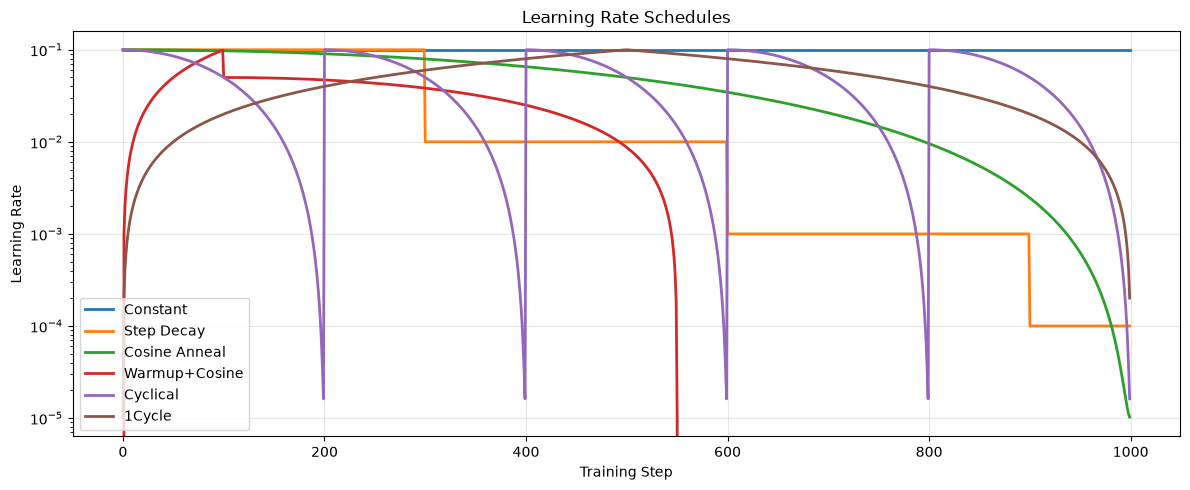

In [3]:
import numpy as np
import matplotlib.pyplot as plt

T = 1000  # total steps
t = np.arange(T)
lr_max, lr_min = 0.1, 1e-5
warmup = 100

schedules = {}

# Constant
schedules['Constant'] = np.full(T, lr_max)

# Step decay
schedules['Step Decay'] = lr_max * 0.1**(t // 300)

# Cosine annealing
schedules['Cosine Anneal'] = lr_min + 0.5*(lr_max-lr_min)*(1 + np.cos(np.pi*t/T))

# Linear warmup + cosine decay
warmup_schedule = np.where(
    t < warmup,
    lr_max * t / warmup,
    lr_min + 0.5*(lr_max-lr_min)*np.cos(np.pi*(t-warmup)/(T-warmup))
)
schedules['Warmup+Cosine'] = warmup_schedule

# Cyclical
cycle_len = 200
schedules['Cyclical'] = lr_min + 0.5*(lr_max-lr_min)*(1 + np.cos(np.pi*(t % cycle_len)/cycle_len))

# 1Cycle
half = T // 2
up = lr_min + (lr_max-lr_min) * t[:half] / half
down = lr_max + (lr_min/10-lr_max) * (t[half:]-half) / (T-half)
schedules['1Cycle'] = np.concatenate([up, down])

fig, ax = plt.subplots(figsize=(12, 5))
for name, sched in schedules.items():
    ax.plot(t, sched, linewidth=2, label=name)

ax.set_xlabel('Training Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedules')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Second-Order Methods

### Newton's Method
Uses the Hessian for curvature-aware updates:
$$\theta_{t+1} = \theta_t - H^{-1} \nabla\mathcal{L}(\theta_t)$$

**Convergence:** Quadratic near the optimum. Very fast!
**Problem:** Computing $H^{-1}$ costs $O(n^2)$ space and $O(n^3)$ time. For a 175B parameter GPT: **computationally impossible**.

### L-BFGS (Limited-memory BFGS)
Approximates the inverse Hessian using only the last $k$ gradient vectors. Works well for small-medium ML problems (e.g., logistic regression, small NNs). Not used in deep learning with mini-batches.

### Natural Gradient
Uses Fisher information matrix $F$ instead of Hessian:
$$\theta_{t+1} = \theta_t - \alpha F^{-1} \nabla\mathcal{L}$$
Invariant to parameterization. Used in **TRPO/PPO** (reinforcement learning).

### Shampoo (2018)
Full-matrix AdaGrad with Kronecker factoring. State-of-art at Google for large-scale training.

## 10. Constrained Optimization

### Lagrange Multipliers
**Problem:** $\min_x f(x)$ subject to $g(x) = 0$

**Method:** Form the Lagrangian:
$$\mathcal{L}(x, \lambda) = f(x) + \lambda g(x)$$

**Condition:** $\nabla_x f = -\lambda \nabla_x g$ (gradients are parallel)

### KKT Conditions
**Problem:** $\min_x f(x)$ subject to $g_i(x) \leq 0$, $h_j(x) = 0$

**KKT conditions** (necessary for optimality):
1. **Stationarity:** $\nabla_x f + \sum_i \mu_i \nabla_x g_i + \sum_j \lambda_j \nabla_x h_j = 0$
2. **Primal feasibility:** $g_i(x) \leq 0$, $h_j(x) = 0$
3. **Dual feasibility:** $\mu_i \geq 0$
4. **Complementary slackness:** $\mu_i g_i(x) = 0$

**In ML:** SVM optimization is a constrained QP solved via KKT. TRPO uses trust-region constraint.

## 11. Practical Optimization Tips

### Gradient Clipping
Prevents exploding gradients (common in RNNs, Transformers):
$$\text{if } \|g\| > \text{clip\_value}: \quad g \leftarrow \frac{g}{\|g\|} \cdot \text{clip\_value}$$

### Gradient Accumulation
Simulate large batch size with limited memory:
```python
for i, batch in enumerate(dataloader):
    loss = model(batch) / accumulation_steps
    loss.backward()
    if (i+1) % accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()
```

### Weight Initialization Matters
- **Xavier/Glorot:** $W \sim \mathcal{U}[-\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}}, \frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}}]$ for sigmoid/tanh
- **He/Kaiming:** $W \sim \mathcal{N}(0, \sqrt{\frac{2}{n_{in}}})$ for ReLU
- Bad initialization → vanishing/exploding gradients → training failure

### Batch Normalization Effect on Optimization
BN smoothens the loss landscape → can use higher learning rates → faster convergence.

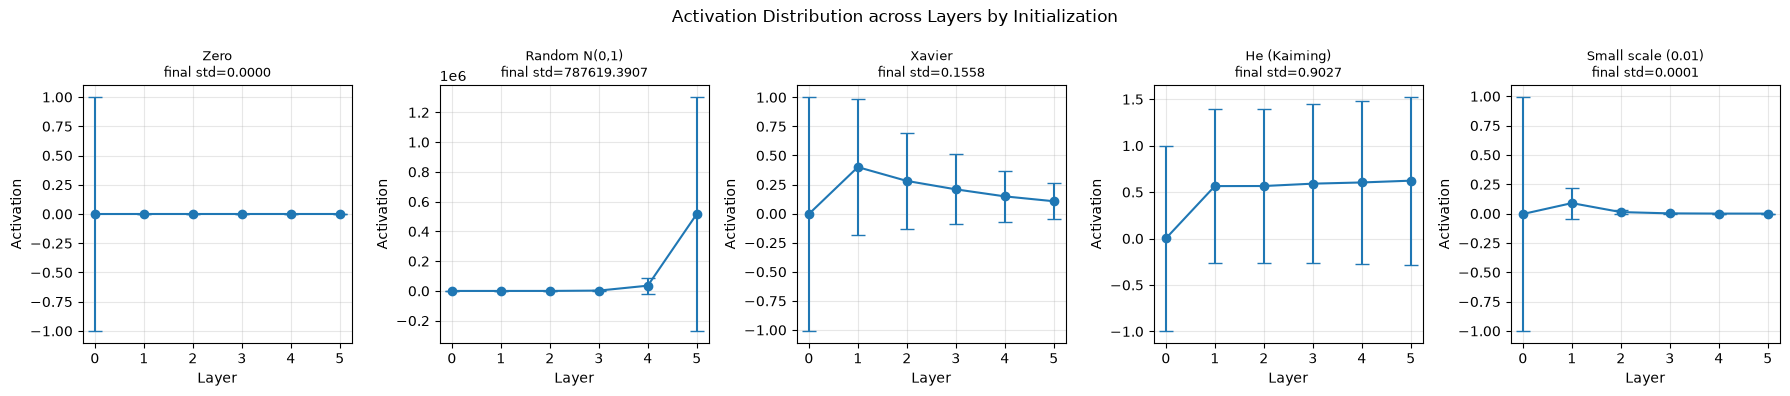

Observation:
- Zero init: all activations = 0 (no learning)
- Random N(0,1): explodes (std grows exponentially)
- Xavier: good for sigmoid/tanh
- He (Kaiming): good for ReLU (maintains std ≈ 1)
- Small scale (0.01): vanishes (std shrinks exponentially)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Weight initialization comparison
np.random.seed(42)
n_in, n_out = 512, 512

inits = {
    'Zero': np.zeros((n_in, n_out)),
    'Random N(0,1)': np.random.randn(n_in, n_out),
    'Xavier': np.random.uniform(-np.sqrt(6/(n_in+n_out)), np.sqrt(6/(n_in+n_out)), (n_in, n_out)),
    'He (Kaiming)': np.random.randn(n_in, n_out) * np.sqrt(2/n_in),
    'Small scale (0.01)': np.random.randn(n_in, n_out) * 0.01,
}

def relu(x): return np.maximum(0, x)

fig, axes = plt.subplots(1, len(inits), figsize=(18, 4))

for ax, (name, W) in zip(axes, inits.items()):
    # Forward pass through 5 relu layers
    x = np.random.randn(100, n_in)
    activations = [x]
    for _ in range(5):
        x = relu(x @ W)
        activations.append(x)
    
    means = [a.mean() for a in activations]
    stds = [a.std() for a in activations]
    
    layers = range(len(activations))
    ax.errorbar(layers, means, yerr=stds, fmt='o-', capsize=5)
    ax.set_title(f'{name}\nfinal std={stds[-1]:.4f}', fontsize=9)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Activation')
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Distribution across Layers by Initialization', fontsize=12)
plt.tight_layout()
plt.show()

print("Observation:")
print("- Zero init: all activations = 0 (no learning)")
print("- Random N(0,1): explodes (std grows exponentially)")
print("- Xavier: good for sigmoid/tanh")
print("- He (Kaiming): good for ReLU (maintains std ≈ 1)")
print("- Small scale (0.01): vanishes (std shrinks exponentially)")

## Additional Learning Resources

### Video Courses
- **CS229 Optimization Notes**: https://cs229.stanford.edu/notes2022fall/cs229-notes1.pdf
- **Fast.ai Optimization**: https://course.fast.ai/
- **CMU 10-725 Convex Optimization**: https://www.stat.cmu.edu/~ryantibs/convexopt/
- **Stanford EE364a Convex Optimization**: https://ee364a.stanford.edu/

### Books
- **Convex Optimization Boyd & Vandenberghe (Free PDF)**: https://web.stanford.edu/~boyd/cvxbook/
- **Numerical Optimization Nocedal & Wright**: https://link.springer.com/book/10.1007/978-0-387-40065-5
- **Deep Learning Book Ch 8 (Optimization)**: https://www.deeplearningbook.org/contents/optimization.html

### Papers
- **Adam: A Method for Stochastic Optimization**: https://arxiv.org/abs/1412.6980
- **AdamW Decoupled Weight Decay**: https://arxiv.org/abs/1711.05101
- **Super-Convergence (1Cycle)**: https://arxiv.org/abs/1708.07120
- **Lion Optimizer**: https://arxiv.org/abs/2302.06675
- **LAMB Optimizer (large batch BERT)**: https://arxiv.org/abs/1904.00962
- **Shampoo Optimizer**: https://arxiv.org/abs/1802.09568
- **On the Importance of Initialization**: https://proceedings.mlr.press/v9/glorot10a.html
- **Delving Deep into Rectifiers (He init)**: https://arxiv.org/abs/1502.01852
- **An Overview of Gradient Descent Optimization (Ruder 2016)**: https://arxiv.org/abs/1609.04747